<a href="https://colab.research.google.com/github/pandey06/Deep-Learning-/blob/main/Assignment_6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install -q kagglehub

In [ ]:
import kagglehub
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import os

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


In [ ]:
path = kagglehub.dataset_download(
    "emmarex/plantdisease"
)

print("Dataset downloaded to:")
print(path)

Using Colab cache for faster access to the 'plantdisease' dataset.
Dataset downloaded to:
/kaggle/input/plantdisease


In [ ]:
print("Files and folders in dataset:")

for root, dirs, files in os.walk(path):

    print("\nFolder:", root)
    print("Subfolders:", dirs[:10])

    if len(files) > 0:
        print("Number of files:", len(files))

Files and folders in dataset:

Folder: /kaggle/input/plantdisease
Subfolders: ['PlantVillage', 'plantvillage']

Folder: /kaggle/input/plantdisease/PlantVillage
Subfolders: ['Pepper__bell___Bacterial_spot', 'Potato___healthy', 'Tomato_Leaf_Mold', 'Tomato__Tomato_YellowLeaf__Curl_Virus', 'Tomato_Bacterial_spot', 'Tomato_Septoria_leaf_spot', 'Tomato_healthy', 'Tomato_Spider_mites_Two_spotted_spider_mite', 'Tomato_Early_blight', 'Tomato__Target_Spot']

Folder: /kaggle/input/plantdisease/PlantVillage/Pepper__bell___Bacterial_spot
Subfolders: []
Number of files: 997

Folder: /kaggle/input/plantdisease/PlantVillage/Potato___healthy
Subfolders: []
Number of files: 152

Folder: /kaggle/input/plantdisease/PlantVillage/Tomato_Leaf_Mold
Subfolders: []
Number of files: 952

Folder: /kaggle/input/plantdisease/PlantVillage/Tomato__Tomato_YellowLeaf__Curl_Virus
Subfolders: []
Number of files: 3209

Folder: /kaggle/input/plantdisease/PlantVillage/Tomato_Bacterial_spot
Subfolders: []
Number of files: 21

In [ ]:
dataset_path = os.path.join(path, "PlantVillage")

print("Dataset path:")
print(dataset_path)

print("\nAvailable classes:")

for folder in os.listdir(dataset_path):
    print(folder)

Dataset path:
/kaggle/input/plantdisease/PlantVillage

Available classes:
Pepper__bell___Bacterial_spot
Potato___healthy
Tomato_Leaf_Mold
Tomato__Tomato_YellowLeaf__Curl_Virus
Tomato_Bacterial_spot
Tomato_Septoria_leaf_spot
Tomato_healthy
Tomato_Spider_mites_Two_spotted_spider_mite
Tomato_Early_blight
Tomato__Target_Spot
Pepper__bell___healthy
Potato___Late_blight
Tomato_Late_blight
Potato___Early_blight
Tomato__Tomato_mosaic_virus


In [ ]:
tomato_classes = [
    folder
    for folder in os.listdir(dataset_path)
    if folder.startswith("Tomato")
]

print("Tomato disease classes:")

for folder in tomato_classes:
    print(folder)

print("\nNumber of tomato classes:", len(tomato_classes))

Tomato disease classes:
Tomato_Leaf_Mold
Tomato__Tomato_YellowLeaf__Curl_Virus
Tomato_Bacterial_spot
Tomato_Septoria_leaf_spot
Tomato_healthy
Tomato_Spider_mites_Two_spotted_spider_mite
Tomato_Early_blight
Tomato__Target_Spot
Tomato_Late_blight
Tomato__Tomato_mosaic_virus

Number of tomato classes: 10


In [ ]:
import shutil

tomato_path = "/content/tomato_dataset"

os.makedirs(tomato_path, exist_ok=True)

for class_name in tomato_classes:

    source = os.path.join(
        dataset_path,
        class_name
    )

    destination = os.path.join(
        tomato_path,
        class_name
    )

    shutil.copytree(
        source,
        destination,
        dirs_exist_ok=True
    )

print("Tomato dataset prepared successfully!")

Tomato dataset prepared successfully!


In [ ]:
IMG_SIZE = (128, 128)
BATCH_SIZE = 32

train_ds = tf.keras.utils.image_dataset_from_directory(

    tomato_path,

    validation_split=0.2,

    subset="training",

    seed=123,

    image_size=IMG_SIZE,

    batch_size=BATCH_SIZE
)

val_ds = tf.keras.utils.image_dataset_from_directory(

    tomato_path,

    validation_split=0.2,

    subset="validation",

    seed=123,

    image_size=IMG_SIZE,

    batch_size=BATCH_SIZE
)

class_names = train_ds.class_names

print("\nClasses:")

for i, name in enumerate(class_names):
    print(i, ":", name)

Found 16011 files belonging to 10 classes.
Using 12809 files for training.
Found 16011 files belonging to 10 classes.
Using 3202 files for validation.

Classes:
0 : Tomato_Bacterial_spot
1 : Tomato_Early_blight
2 : Tomato_Late_blight
3 : Tomato_Leaf_Mold
4 : Tomato_Septoria_leaf_spot
5 : Tomato_Spider_mites_Two_spotted_spider_mite
6 : Tomato__Target_Spot
7 : Tomato__Tomato_YellowLeaf__Curl_Virus
8 : Tomato__Tomato_mosaic_virus
9 : Tomato_healthy


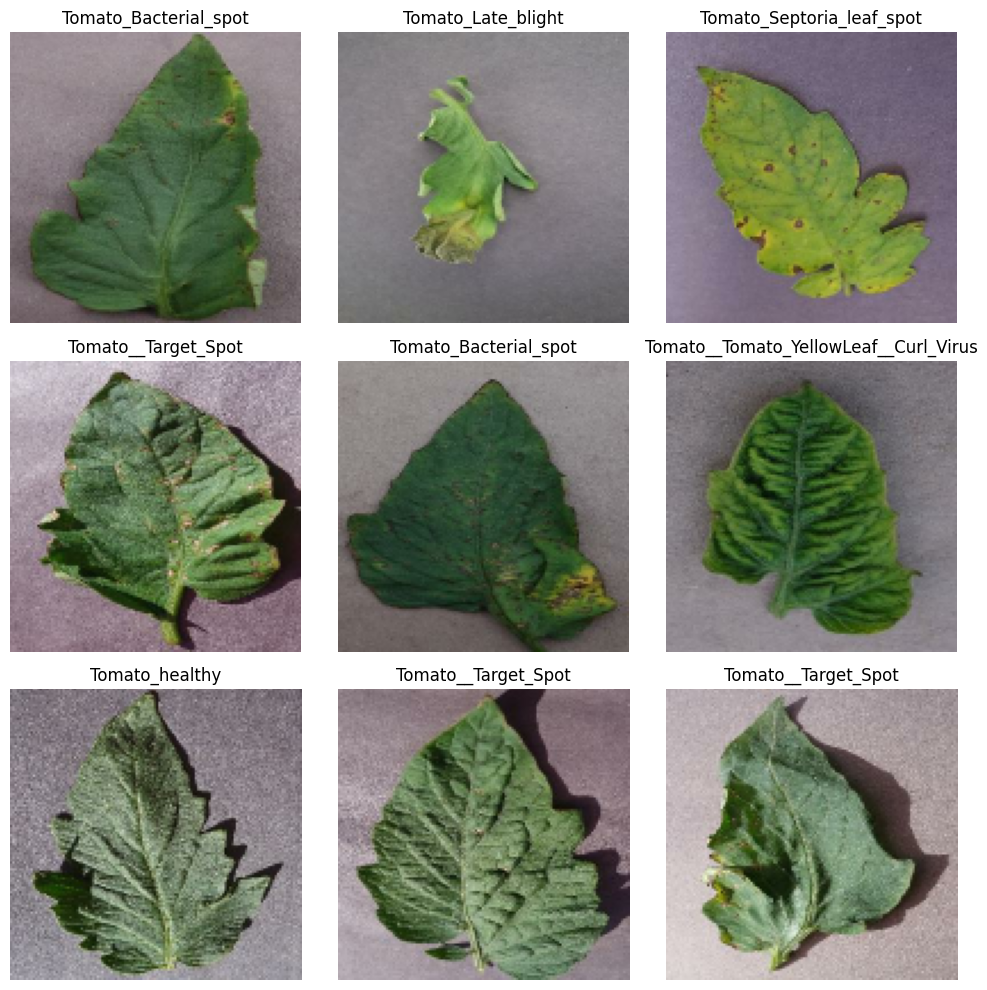

In [ ]:
plt.figure(figsize=(10, 10))

for images, labels in train_ds.take(1):

    for i in range(9):

        plt.subplot(3, 3, i + 1)

        plt.imshow(
            images[i].numpy().astype("uint8")
        )

        plt.title(
            class_names[labels[i]]
        )

        plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.cache().shuffle(1000).prefetch(
    buffer_size=AUTOTUNE
)

val_ds = val_ds.cache().prefetch(
    buffer_size=AUTOTUNE
)

In [ ]:
model = tf.keras.Sequential([

    # Normalize pixels
    tf.keras.layers.Rescaling(
        1./255,
        input_shape=(128, 128, 3)
    ),

    # Conv Block 1
    tf.keras.layers.Conv2D(
        32,
        (3, 3),
        activation="relu"
    ),

    tf.keras.layers.MaxPooling2D(
        (2, 2)
    ),

    # Conv Block 2
    tf.keras.layers.Conv2D(
        64,
        (3, 3),
        activation="relu"
    ),

    tf.keras.layers.MaxPooling2D(
        (2, 2)
    ),

    # Conv Block 3
    tf.keras.layers.Conv2D(
        128,
        (3, 3),
        activation="relu"
    ),

    tf.keras.layers.MaxPooling2D(
        (2, 2)
    ),

    # Flatten
    tf.keras.layers.Flatten(),

    # Dense
    tf.keras.layers.Dense(
        128,
        activation="relu"
    ),

    # Dropout
    tf.keras.layers.Dropout(0.5),

    # Output
    tf.keras.layers.Dense(
        len(class_names),
        activation="softmax"
    )
])

model.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/preprocessing/data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,305,930 (12.61 MB)

 Trainable params: 3,305,930 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(

    optimizer="adam",

    loss="sparse_categorical_crossentropy",

    metrics=["accuracy"]
)

print("Model compiled successfully!")

Model compiled successfully!


In [ ]:
EPOCHS = 10

history = model.fit(

    train_ds,

    validation_data=val_ds,

    epochs=EPOCHS
)

Epoch 1/10
401/401 ━━━━━━━━━━━━━━━━━━━━ 535s 1s/step - accuracy: 0.5313 - loss: 1.3426 - val_accuracy: 0.7867 - val_loss: 0.6666
Epoch 2/10
401/401 ━━━━━━━━━━━━━━━━━━━━ 525s 1s/step - accuracy: 0.7428 - loss: 0.7526 - val_accuracy: 0.8554 - val_loss: 0.4260
Epoch 3/10
401/401 ━━━━━━━━━━━━━━━━━━━━ 494s 1s/step - accuracy: 0.7938 - loss: 0.5985 - val_accuracy: 0.8507 - val_loss: 0.4334
Epoch 4/10
401/401 ━━━━━━━━━━━━━━━━━━━━ 490s 1s/step - accuracy: 0.8273 - loss: 0.5082 - val_accuracy: 0.8954 - val_loss: 0.2928
Epoch 5/10
401/401 ━━━━━━━━━━━━━━━━━━━━ 489s 1s/step - accuracy: 0.8480 - loss: 0.4382 - val_accuracy: 0.9160 - val_loss: 0.2494
Epoch 6/10
401/401 ━━━━━━━━━━━━━━━━━━━━ 502s 1s/step - accuracy: 0.8710 - loss: 0.3818 - val_accuracy: 0.9204 - val_loss: 0.2384
Epoch 7/10
401/401 ━━━━━━━━━━━━━━━━━━━━ 491s 1s/step - accuracy: 0.8746 - loss: 0.3623 - val_accuracy: 0.9154 - val_loss: 0.2416
Epoch 8/10
401/401 ━━━━━━━━━━━━━━━━━━━━ 509s 1s/step - accuracy: 0.8925 - loss: 0.3130 - val_accu

In [ ]:
loss, accuracy = model.evaluate(val_ds)

print("Validation Loss:", loss)

print(
    "Validation Accuracy:",
    accuracy
)

print(
    "Validation Accuracy (%):",
    accuracy * 100
)

101/101 ━━━━━━━━━━━━━━━━━━━━ 32s 313ms/step - accuracy: 0.9263 - loss: 0.2367
Validation Loss: 0.23667611181735992
Validation Accuracy: 0.926296055316925
Validation Accuracy (%): 92.6296055316925


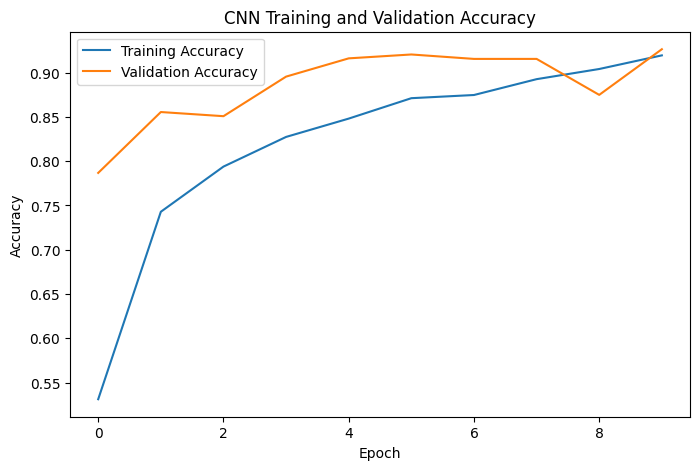

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(
    history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.title(
    "CNN Training and Validation Accuracy"
)

plt.legend()

plt.show()

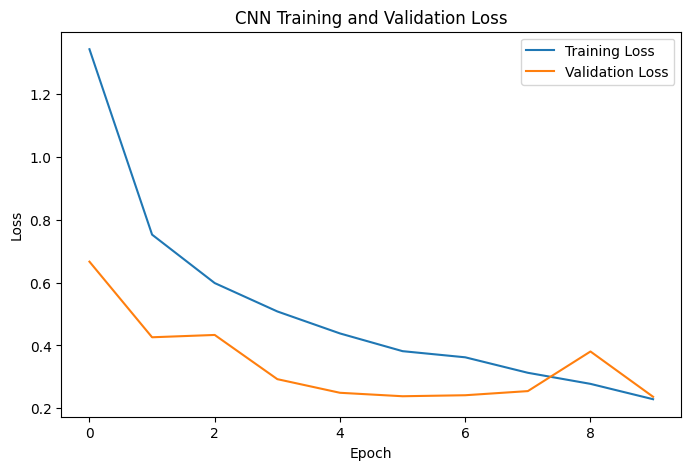

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(
    history.history["loss"],
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.title(
    "CNN Training and Validation Loss"
)

plt.legend()

plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 172ms/step
Actual Disease: Tomato_healthy
Predicted Disease: Tomato_healthy
Confidence: 99.92 %


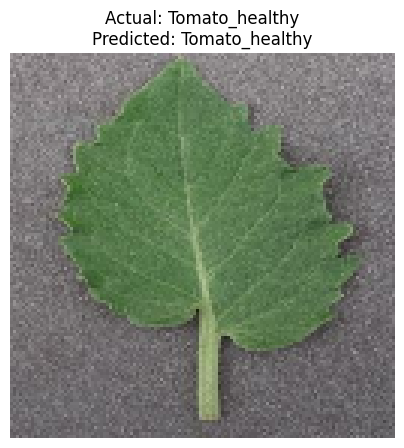

In [ ]:
for images, labels in val_ds.take(1):

    image = images[0]

    actual_label = labels[0].numpy()

    image_batch = tf.expand_dims(
        image,
        axis=0
    )

    prediction = model.predict(
        image_batch
    )

    predicted_label = np.argmax(
        prediction[0]
    )

    confidence = (
        np.max(prediction[0]) * 100
    )

    print(
        "Actual Disease:",
        class_names[actual_label]
    )

    print(
        "Predicted Disease:",
        class_names[predicted_label]
    )

    print(
        "Confidence:",
        round(confidence, 2),
        "%"
    )

    plt.figure(figsize=(5, 5))

    plt.imshow(
        image.numpy().astype("uint8")
    )

    plt.title(
        f"Actual: {class_names[actual_label]}\n"
        f"Predicted: {class_names[predicted_label]}"
    )

    plt.axis("off")

    plt.show()

    break